# 长短期记忆网络 LSTM

## 基础知识

在标准 RNN 和 GRU 中，$H$ 既是**记忆**又是**输出**，更新时频繁使用矩阵乘法（$W⋅H$），导致梯度在长序列中极易消失。

LSTM 可以把记忆（C）和输出（H）分开，且$H$ 保持在[-1,1]之间，防止梯度爆炸

- 模型输出结果都是 $H_t$

- 任务最终预测结果都是：$ Y = H·W + b $


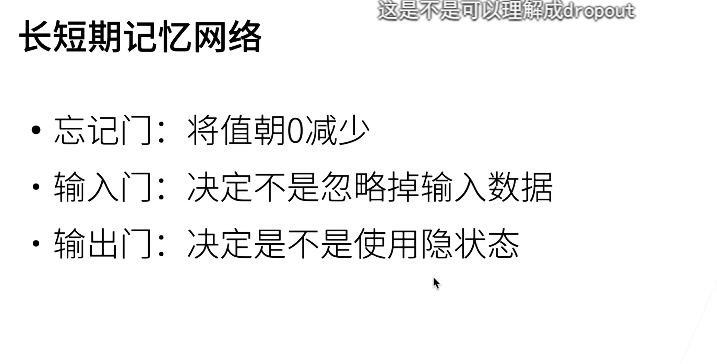

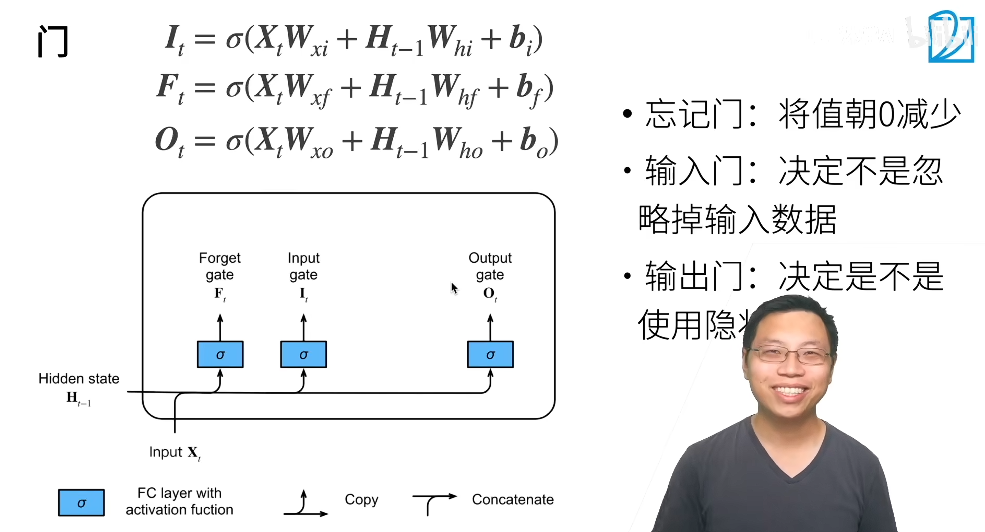

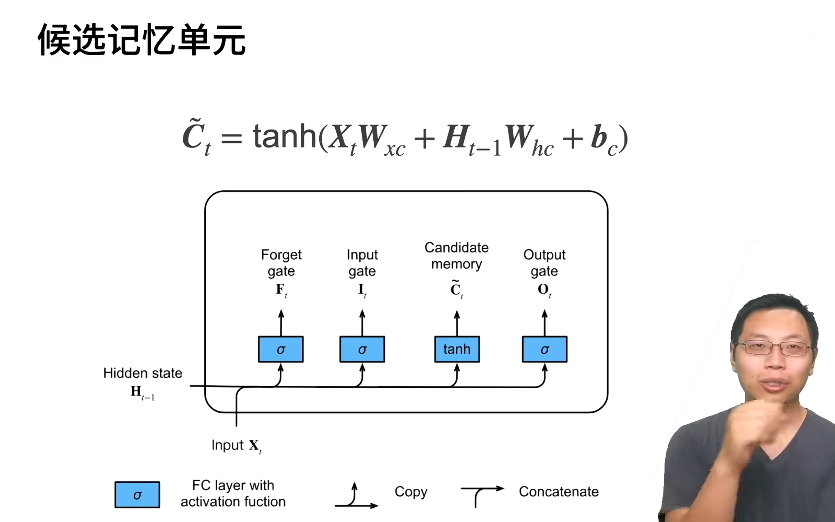

候选记忆单元通过输入和隐状态计算

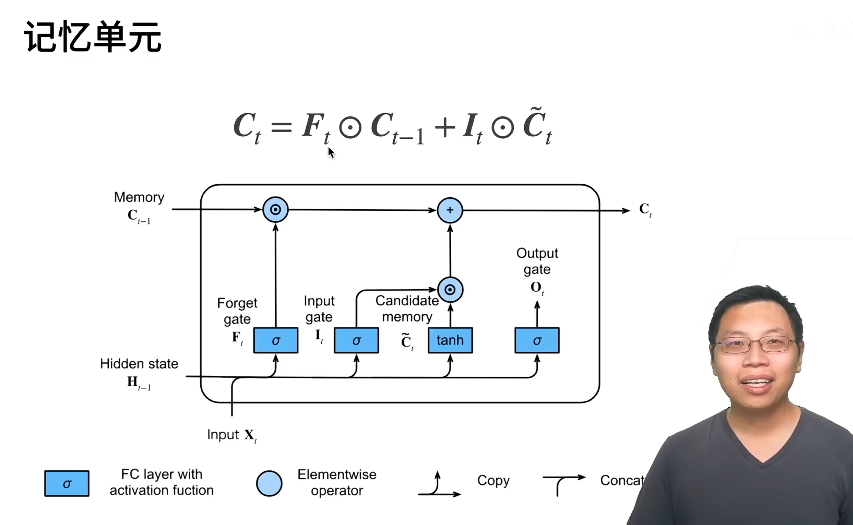

$C_t$ 是长期记忆，贯穿整个网络，信息在上面流动时改动很少

输入门 $I_t$ 控制采用多少来自候选记忆单元的新数据

而遗忘门 $F_t$ 控制保留多少过去的记忆元的内容。

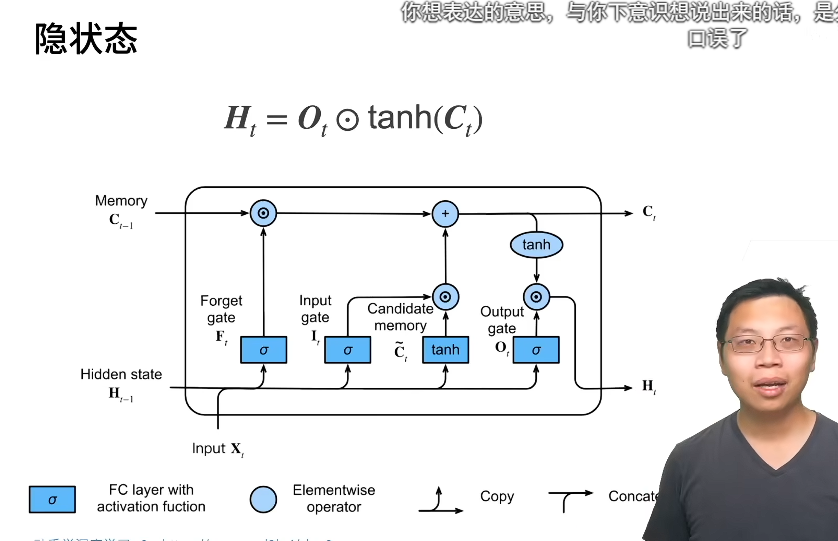

$H_t$ 是短期记忆，从记忆单元 $C_t$ 中筛选出当前最需要展示给外界的信息。

输出门 $O_t$ 决定记忆单元的保留程度，当输出门接近 0 时不更新隐状态。H 保持在[-1,1]之间，防止梯度爆炸

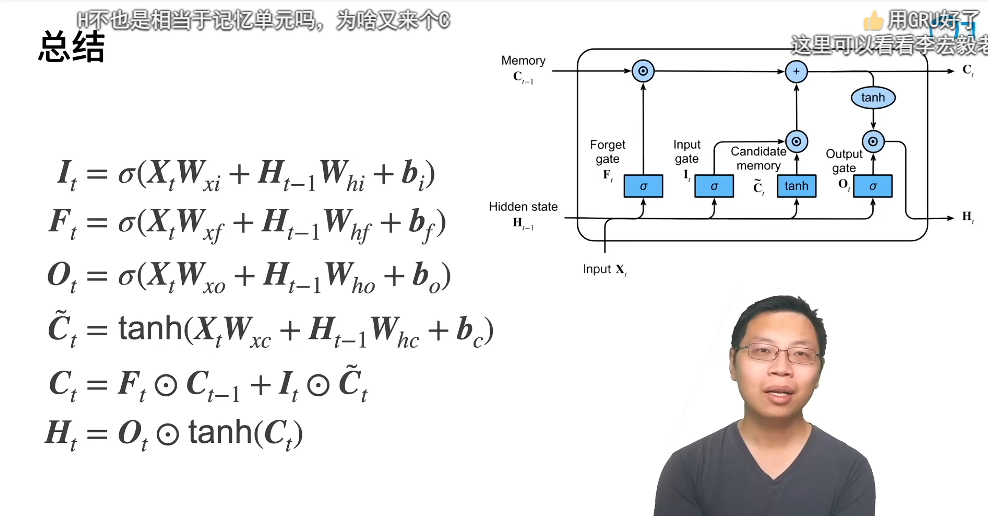

比 GRU 多一个 C，C可以保留上一个 C 的信息，也可以加上新的 C 的信息。

https://www.bilibili.com/video/BV1Z34y1k7mc/?share_source=copy_web&spm_id_from=333.788.comment.all.click&vd_source=c86288548edd2f1c9703f6ffd318fa53

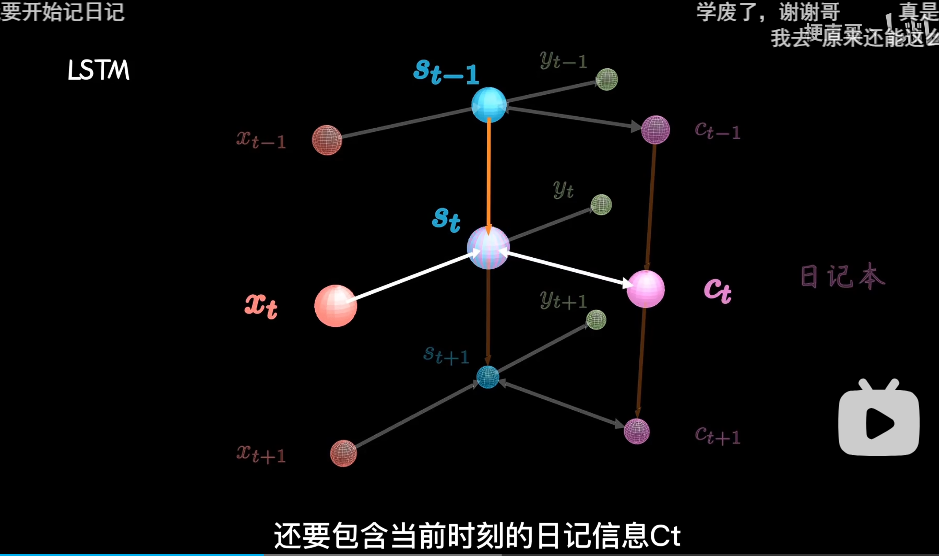

比 RNN 多一个 C 记忆状态，并有两个决定 C 的门，input gate和forget gate

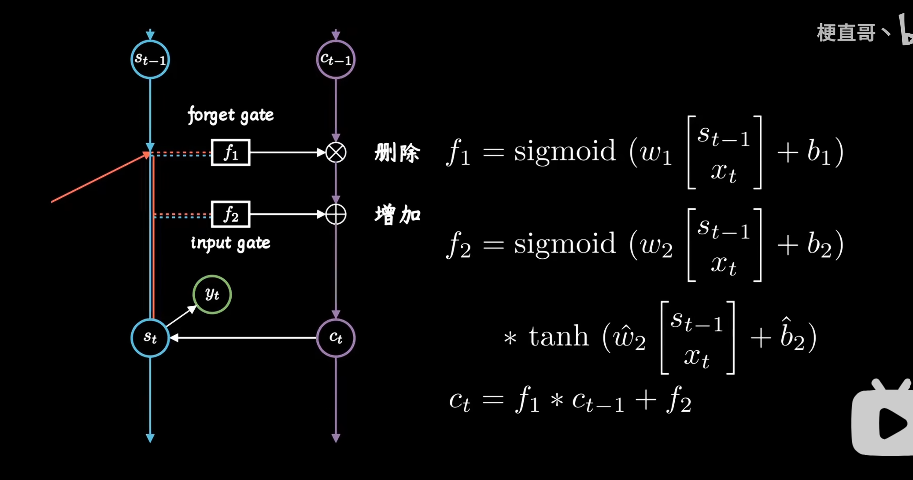

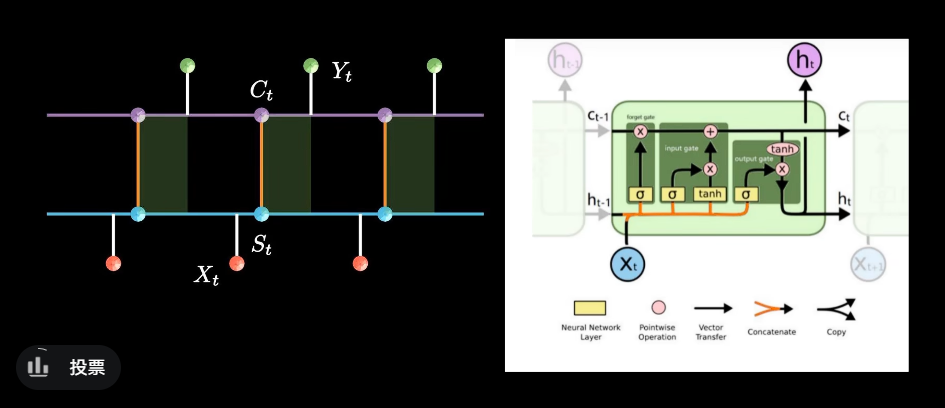

C 和 H 往后传，输出 Y 往上传

## 代码

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

In [2]:
def get_lstm_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xi, W_hi, b_i = three()  # 输入门参数
    W_xf, W_hf, b_f = three()  # 遗忘门参数
    W_xo, W_ho, b_o = three()  # 输出门参数
    W_xc, W_hc, b_c = three()  # 候选记忆元参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc,
              b_c, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

In [3]:
def init_lstm_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),
            torch.zeros((batch_size, num_hiddens), device=device))

In [4]:
def lstm(inputs, state, params):
    [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc, b_c,
     W_hq, b_q] = params
    (H, C) = state
    outputs = []
    for X in inputs:
        I = torch.sigmoid((X @ W_xi) + (H @ W_hi) + b_i)
        F = torch.sigmoid((X @ W_xf) + (H @ W_hf) + b_f)
        O = torch.sigmoid((X @ W_xo) + (H @ W_ho) + b_o)
        C_tilda = torch.tanh((X @ W_xc) + (H @ W_hc) + b_c)
        C = F * C + I * C_tilda
        H = O * torch.tanh(C)
        Y = (H @ W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H, C)

perplexity 1.1, 2453.2 tokens/sec on cpu
time traveller for so it will be convenient to speak of himwas e
travellery i dimfncickeding i gomt beak ithit is filby the 


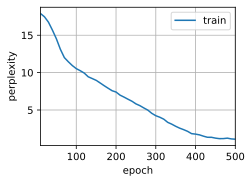

In [5]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_lstm_params,
                            init_lstm_state, lstm)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

简洁实现

perplexity 1.1, 21474.8 tokens/sec on cpu
time traveller for so it will be convenient to speak of himwas e
traveller with a slight accession ofcheerfulness really thi


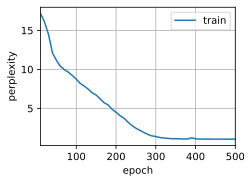

In [6]:
num_inputs = vocab_size
lstm_layer = nn.LSTM(num_inputs, num_hiddens)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)